In [2]:
# Paquete Numpy
import numpy as np

# Módulo para las gráficas
from matplotlib import pyplot as plt

# Matematicas simbolicas
import sympy as sp

Transformada inversa para distribucion uniforme

0.333333333333333*x
[0.83449388 1.39690175 0.66720606 ... 1.11078176 2.85892769 1.57496776]


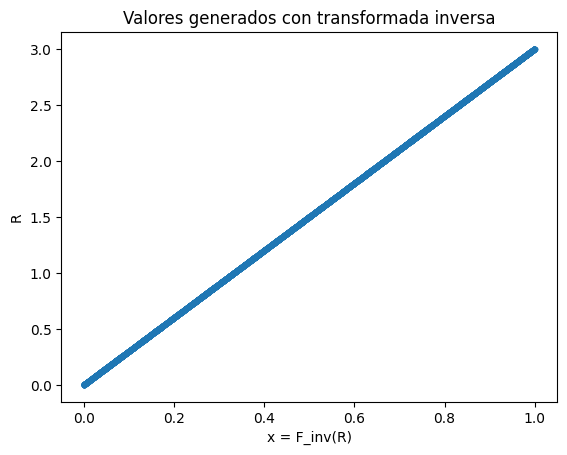

In [ ]:


# Definimos la variable y la función
b=5
a=2
x = sp.symbols('x')

f = (1/(b-a))*x**0  # funcion

# Definimos la variable para la inversa
y = sp.symbols('y')
#1. Igualamos f(x) a y y despejamos x para encontrar la inversa
F_acum = sp.integrate(f,x)
print(F_acum)
inverse_f = sp.solve(F_acum - y, x)

#2. Obtemenos una distribucion uniforme de numeros pseudoaleatorios R y evaluamos inverse_F en funcion de R
R = np.random.uniform(0,1,10000)
F_inv = sp.lambdify(y, inverse_f[0], modules="numpy")
print(F_inv(R))
X = F_inv(R)

#3. Graficamos 
plt.plot(R, X, '.')

#Etiquetas
plt.ylabel('R')
plt.xlabel('x = F_inv(R)')
plt.title ('Valores generados con transformada inversa(distribucion uniforme)')
plt.show()


Transformada inversa con distribucion exponencial

Función acumulada: 1.0 - 1.0*exp(-0.2*x)
Función inversa: 5.0*log(-1/(y - 1.0))


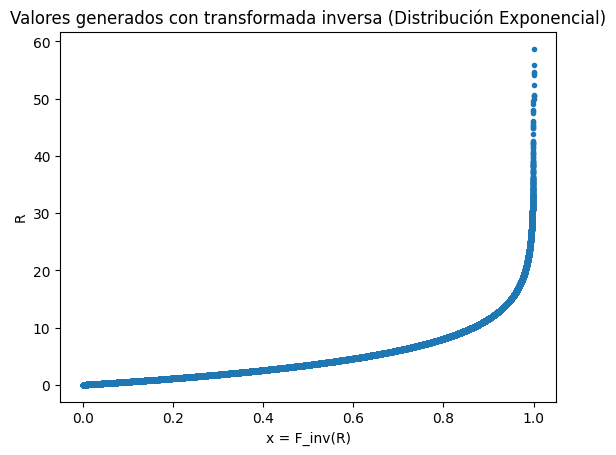

In [ ]:
b = 5
lambda_1 = 1 / b  # Usamos 1/b para el parámetro de la exponencial
x = sp.symbols('x')

# Definimos la función de densidad exponencial
f = lambda_1 * sp.exp(-lambda_1 * x)  # Función de densidad para la exponencial

# Definimos la variable para la inversa
y = sp.symbols('y')
# 1. Calculamos la función de distribución acumulada
F_acum = sp.integrate(f, (x, 0, x))  # Acumulada desde 0 hasta x
print("Función acumulada:", F_acum)

# 2. Despejamos x para obtener la inversa
inverse_f = sp.solve(F_acum - y, x)[0]
print("Función inversa:", inverse_f)

# 3. Generamos una distribución uniforme de números pseudoaleatorios R y evaluamos la función inversa
R = np.random.random(100000)
F_inv = sp.lambdify(y, inverse_f, modules="numpy")
X = F_inv(R)

# 4. Graficamos
plt.plot(R, X, '.')
plt.ylabel('R')
plt.xlabel('x = F_inv(R)')
plt.title('Valores generados con transformada inversa (Distribución Exponencial)')
plt.show()

Transformada inversa para la distribucion de Bernoulli

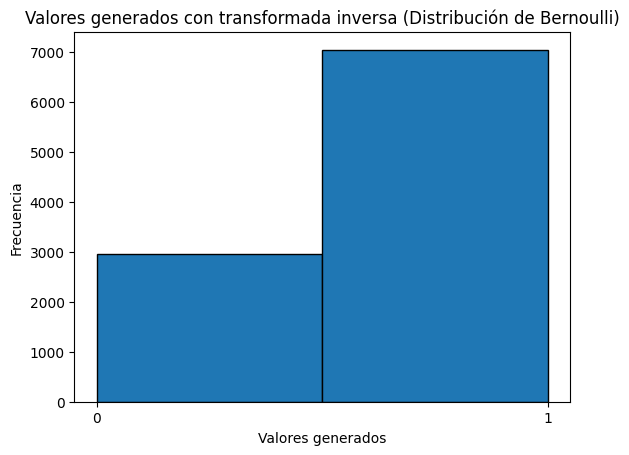

In [7]:
# Definimos el parámetro de probabilidad para la distribución de Bernoulli
p = 0.7  # Probabilidad de obtener un 1

# Generamos una muestra de valores uniformes
R = np.random.uniform(0, 1, 10000)

# Aplicamos la función inversa de la CDF de Bernoulli
X = (R < p).astype(int)  # Genera 1 si R < p, de lo contrario 0

# Graficamos la distribución obtenida
plt.hist(X, bins=2, edgecolor='k', align='mid')
plt.xticks([0, 1])
plt.xlabel('Valores generados')
plt.ylabel('Frecuencia')
plt.title('Valores generados con transformada inversa (Distribución de Bernoulli)')
plt.show()